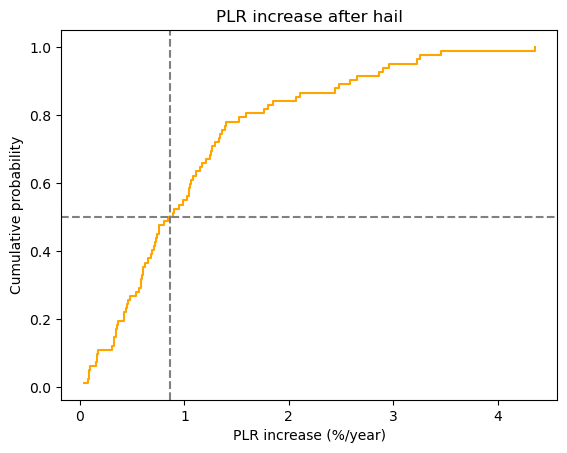

Median = 0.863804142


In [7]:
import numpy as np
import matplotlib.pyplot as plt

data = np.array([
0.887305201,1.33759746,0.605643707,0.482177026,1.040441888,0.330440821,
1.289761597,0.948351328,1.585439242,1.249132495,1.401430431,0.582570831,
0.367227094,0.341319146,2.475747945,1.057204846,0.71346814,1.801832572,
1.757602627,2.586020923,1.207721209,0.174357962,0.738424583,0.455014414,
0.727880193,0.302266519,1.146095062,0.693564532,0.154716991,1.264410568,
0.165077035,0.594292259,1.065974589,2.95449976,1.08559459,0.801934813,
1.16532407,1.364242642,1.107618498,0.582817407,1.519659147,0.351822552,
0.418617494,2.901288924,0.759082962,0.900971907,0.715145655,4.355638934,
1.32867296,2.65619456,2.861304705,0.567083481,3.225851231,1.039881884,
0.16228571,3.457936675,0.073855277,2.072638044,0.647884245,2.111528228,
0.539578263,2.444206969,0.089499773,3.260276368,0.990221673,1.850995967,
1.386968103,0.682837469,0.752943255,0.346847614,0.099683124,1.022151091,
0.084571064,0.46401544,0.038043401,0.840303083,0.420571456,0.618513698,
0.445226065,1.258427949,0.606748136,0.329230991
])

# sort
x = np.sort(data)

# cumulative probability
y = np.arange(1,len(x)+1)/len(x)

median = np.median(data)

plt.step(x,y,where='post',color='orange')
plt.axhline(0.5,linestyle='--',color='gray')
plt.axvline(median,linestyle='--',color='gray')

plt.xlabel("PLR increase (%/year)")
plt.ylabel("Cumulative probability")
plt.title("PLR increase after hail")

plt.show()

print("Median =",median)

In [12]:
# Safety checks
assert np.all(np.diff(y) >= 0), "CDF y-values must be nondecreasing"
assert y[0] >= 0 and y[-1] <= 1.0 + 1e-9, "CDF must stay within [0,1]"

# Normalize in case final point is not exactly 1
y = y / y[-1]

def sample_from_empirical_cdf(x_vals, cdf_vals, rng=None):
    """
    Inverse-CDF sampler from an empirical CDF.
    Returns one sampled PLR increase value (%/year).
    """
    if rng is None:
        rng = np.random.default_rng()
    u = rng.uniform()
    return np.interp(u, cdf_vals, x_vals)

In [13]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(123)

n_sims = 10000
analysis_period = 25
hail_year = 5              # example: storm happens at start of year 5
baseline_deg = 0.50        # %/year baseline degradation
p_increase = 0.57          # probability of added degradation after hail

extra_deg_samples = np.zeros(n_sims)
annual_deg_matrix = np.full((n_sims, analysis_period), baseline_deg)

for i in range(n_sims):
    hit = rng.uniform() < p_increase
    if hit:
        delta_deg = sample_from_empirical_cdf(x, y, rng=rng)
    else:
        delta_deg = 0.0
    
    extra_deg_samples[i] = delta_deg
    annual_deg_matrix[i, hail_year-1:] = baseline_deg + delta_deg  # hail year onward

In [14]:
year1_energy = 1.0

annual_energy = np.zeros((n_sims, analysis_period))

for i in range(n_sims):
    remaining = 1.0
    for yr in range(analysis_period):
        if yr == 0:
            annual_energy[i, yr] = year1_energy
        else:
            remaining *= (1 - annual_deg_matrix[i, yr-1] / 100.0)
            annual_energy[i, yr] = year1_energy * remaining

lifetime_energy = annual_energy.sum(axis=1)

p50 = np.percentile(lifetime_energy, 50)
p90 = np.percentile(lifetime_energy, 10)   # finance convention: exceeded with 90% probability
p95 = np.percentile(lifetime_energy, 5)

print("Toy model results")
print("P50 lifetime energy:", p50)
print("P90 lifetime energy:", p90)
print("P95 lifetime energy:", p95)
print("Std dev:", lifetime_energy.std())

Toy model results
P50 lifetime energy: 22.93932724436673
P90 lifetime energy: 20.501130555477037
P95 lifetime energy: 19.234110868209378
Std dev: 1.3816372986264482


In [15]:
baseline_matrix = np.full((n_sims, analysis_period), baseline_deg)

baseline_annual_energy = np.zeros((n_sims, analysis_period))
for i in range(n_sims):
    remaining = 1.0
    for yr in range(analysis_period):
        if yr == 0:
            baseline_annual_energy[i, yr] = year1_energy
        else:
            remaining *= (1 - baseline_matrix[i, yr-1] / 100.0)
            baseline_annual_energy[i, yr] = year1_energy * remaining

baseline_lifetime_energy = baseline_annual_energy.sum(axis=1)

print("\nBaseline (no hail-induced extra PLR)")
print("P50:", np.percentile(baseline_lifetime_energy, 50))
print("P90:", np.percentile(baseline_lifetime_energy, 10))
print("Std dev:", baseline_lifetime_energy.std())

print("\nSpread increase")
print("Delta P50:", np.percentile(lifetime_energy, 50) - np.percentile(baseline_lifetime_energy, 50))
print("Delta P90:", np.percentile(lifetime_energy, 10) - np.percentile(baseline_lifetime_energy, 10))
print("Delta std:", lifetime_energy.std() - baseline_lifetime_energy.std())


Baseline (no hail-induced extra PLR)
P50: 23.555951410239732
P90: 23.555951410239732
Std dev: 7.105427357601002e-15

Spread increase
Delta P50: -0.6166241658730023
Delta P90: -3.0548208547626956
Delta std: 1.3816372986264411


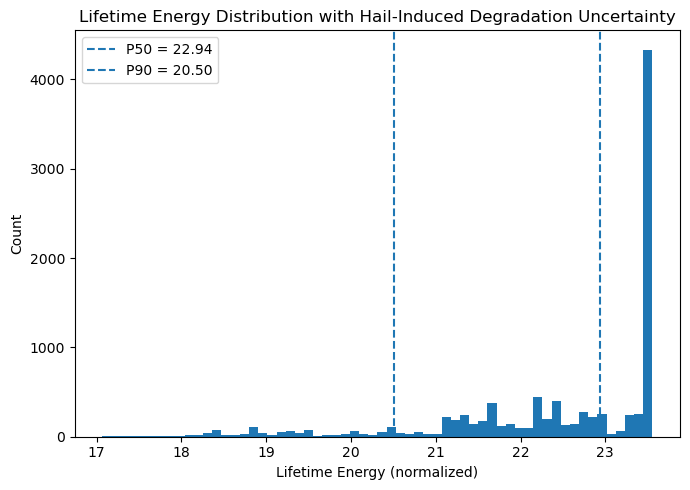

In [16]:
import matplotlib.pyplot as plt
import numpy as np

p50 = np.percentile(lifetime_energy, 50)
p90 = np.percentile(lifetime_energy, 10)

plt.figure(figsize=(7,5))
plt.hist(lifetime_energy, bins=60)

plt.axvline(p50, linestyle="--", label=f"P50 = {p50:.2f}")
plt.axvline(p90, linestyle="--", label=f"P90 = {p90:.2f}")

plt.xlabel("Lifetime Energy (normalized)")
plt.ylabel("Count")
plt.title("Lifetime Energy Distribution with Hail-Induced Degradation Uncertainty")
plt.legend()
plt.tight_layout()
plt.show()

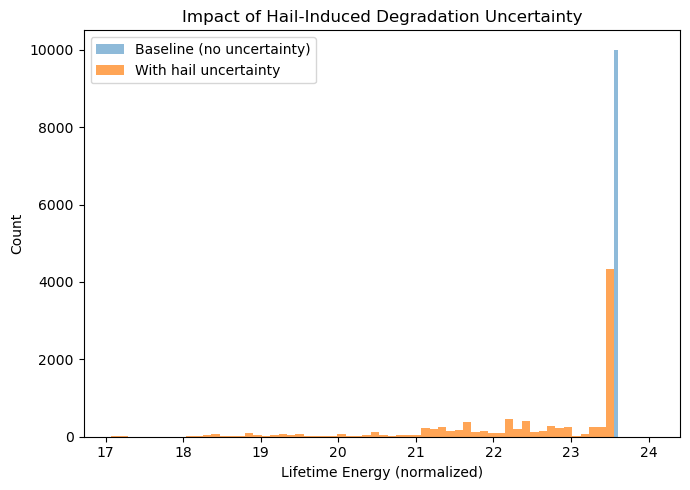

In [17]:
plt.figure(figsize=(7,5))

# Baseline = single value → fake a tight distribution for visualization
baseline_vals = np.full_like(lifetime_energy, baseline_lifetime_energy[0])

plt.hist(baseline_vals, bins=20, alpha=0.5, label="Baseline (no uncertainty)")
plt.hist(lifetime_energy, bins=60, alpha=0.7, label="With hail uncertainty")

plt.xlabel("Lifetime Energy (normalized)")
plt.ylabel("Count")
plt.title("Impact of Hail-Induced Degradation Uncertainty")
plt.legend()
plt.tight_layout()
plt.show()

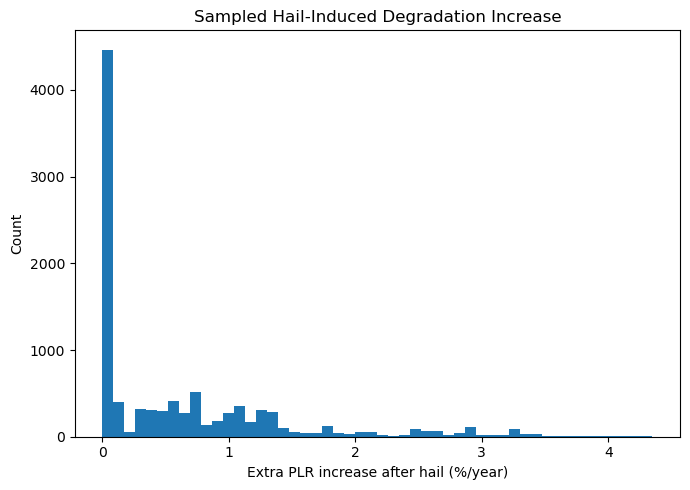

In [18]:
plt.figure(figsize=(7,5))
plt.hist(extra_deg_samples, bins=50)

plt.xlabel("Extra PLR increase after hail (%/year)")
plt.ylabel("Count")
plt.title("Sampled Hail-Induced Degradation Increase")
plt.tight_layout()
plt.show()